In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/retail_sales_dataset.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 120,000 rows x 17 columns


The dataset contains 120,000 transactions with 17 columns.

## 1. Dataset overview
First look at the structure, column types, and a sample of raw values.

In [3]:
df.head(5)

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [4]:
df.dtypes

transaction_id         object
transaction_date       object
customer_id            object
customer_gender        object
customer_age_group     object
customer_segment       object
product_id             object
product_name           object
category               object
brand                  object
quantity                int64
unit_price            float64
discount_pct            int64
sales_amount          float64
payment_method         object
sales_channel          object
region                 object
dtype: object

The following columns have a wrong data type, they need conversion:

* transaction date - It is object, needs datetime

In [5]:
df.describe(include='all')

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
count,120000,120000,120000,120000,120000,120000,120000,120000,120000,120000,120000.000000,120000.000000,120000.000000,120000.000000,120000,120000,120000
unique,120000,730,24784,3,5,4,120,40,8,3,NaN,NaN,NaN,NaN,5,3,5
top,T0119984,2025-07-06,C023479,Female,35-44,VIP,P1016,Dumbbells,Sports,Brand 1,NaN,NaN,NaN,NaN,Credit Card,Mobile App,Central
freq,1,200,15,40268,24196,30115,1096,3108,15218,40240,NaN,NaN,NaN,NaN,24262,40204,24244
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.662908,240.621785,5.496500,377.975454,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.014291,146.457057,8.193257,356.893357,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,7.730000,0.000000,5.410000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,102.010000,0.000000,136.860000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,238.750000,0.000000,295.980000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,379.000000,10.000000,461.500000,NaN,NaN,NaN


The statistical shows us some interesting information about the sales. First we can see that the sales range is from 5.41 to 2467, indicating a wide variation in transaction sizes. This distribution suggest the prescence of both small purchases and high-value transactions. Analyzing the discount percentages, we can notice that the 50% of the sales were made with no discount, this suggests discounts are not consistently applied and may be used selectively. The product quantity per sale ranges from 1 to 5, these are low quantities which indicates typical retail behavior. To finalize, we can observe that the unit price of a product varies from 7.73 to 493.51, this big variation may suggest the selling of premium products, specifically sports related products as we can see that the most frecquent product category is sports and the most frequent customer segment is VIP.

## 2. Missing values
Checking for nulls across all columns — both count and percentage.

In [6]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
missing[missing['missing_count'] > 0]

,missing_count,missing_pct


In [9]:
missing.shape

(17, 2)

No missing values were found across the 17 columns, the dataset is complete. 

In [10]:
dupe_count = df.duplicated().sum()
print(f"Duplicate rows: {dupe_count}")

# Also check duplicate transaction IDs (should be 0)
dupe_ids = df['transaction_id'].duplicated().sum()
print(f"Duplicate transaction_ids: {dupe_ids}")

Duplicate rows: 0
Duplicate transaction_ids: 0


As it should be expected, no duplicated transactions were found.

## 3. Categorical column inspection
Checking unique values for inconsistencies — typos, mixed casing, unexpected categories.

In [11]:
cat_cols = ['customer_gender', 'customer_age_group', 'category',
            'brand', 'payment_method', 'sales_channel',
            'customer_segment', 'region']

for col in cat_cols:
    vals = df[col].value_counts()
    print(f"\n── {col} ({df[col].nunique()} unique) ──")
    print(vals.to_string())


── customer_gender (3 unique) ──
customer_gender
Female    40268
Other     39906
Male      39826

── customer_age_group (5 unique) ──
customer_age_group
35-44    24196
55+      24078
18-24    23941
45-54    23919
25-34    23866

── category (8 unique) ──
category
Sports         15218
Clothing       15156
Beauty         15073
Groceries      15034
Toys           15022
Electronics    15008
Home           14933
Books          14556

── brand (3 unique) ──
brand
Brand 1    40240
Brand 2    39918
Brand 3    39842

── payment_method (5 unique) ──
payment_method
Credit Card    24262
Cash           24034
PayPal         23998
Debit Card     23897
Gift Card      23809

── sales_channel (3 unique) ──
sales_channel
Mobile App    40204
In-Store      40049
Online        39747

── customer_segment (4 unique) ──
customer_segment
VIP          30115
New          30020
Loyal        30014
Returning    29851

── region (5 unique) ──
region
Central    24244
North      24075
South      24066
West       23950

No misspelling errors like typo, case or unexpected categories found across the categorical variables.

## 4. Numerical column inspection
Checking distributions and outliers for quantity, unit_price, discount_pct, and sales_amount.

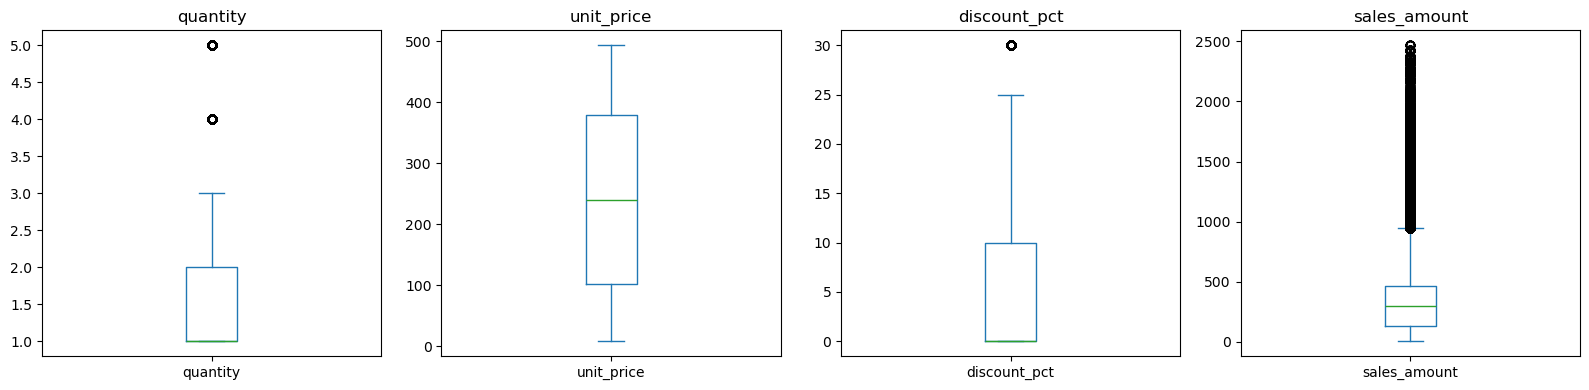

In [12]:
num_cols = ['quantity', 'unit_price', 'discount_pct', 'sales_amount']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    df[col].plot(kind='box', ax=ax, title=col)
plt.tight_layout()
plt.show()

In [13]:
# Logical checks
print("Negative quantities:", (df['quantity'] <= 0).sum())
print("Zero or negative prices:", (df['unit_price'] <= 0).sum())
print("Discount > 100%:", (df['discount_pct'] > 100).sum())
print("Negative sales:", (df['sales_amount'] < 0).sum())

Negative quantities: 0
Zero or negative prices: 0
Discount > 100%: 0
Negative sales: 0


Analyzing the box charts, we can notice that in quantity and discount percentage we can se very few outliers, they reafirm the retail behavior as the quantity outliers are not a high value. For discount percentages it indicates us that a 30% discount on a product is not a common thing but it also is not an extreme value. On the unit price we see no outlier, meaning they sell many products with a similar volume across the price range. And in the sales amount is where we can see the most outliers of all variables by much, this can mean occational big purchases of various expensive products.

## 5. Derived column validation
sales_amount should equal quantity × unit_price × (1 − discount_pct/100). Verifying consistency.

In [20]:
df['expected_sales'] = (
    df['quantity'] * df['unit_price'] * (1 - df['discount_pct'] / 100)
).round(2)

mismatch = df[df['expected_sales'] != df['sales_amount'].round(2)].copy()
mismatch["difference"] = abs(mismatch['expected_sales'] - mismatch['sales_amount'])
print(f"Rows where sales_amount doesn't match formula: {len(mismatch)}")
mismatch[['transaction_id','quantity','unit_price',
          'discount_pct','sales_amount','expected_sales', 'difference']].head()

Rows where sales_amount doesn't match formula: 1083


,transaction_id,quantity,unit_price,discount_pct,sales_amount,expected_sales,difference
75,T0000076,2,264.75,15,450.07,450.08,0.01
92,T0000093,2,482.99,25,724.49,724.48,0.01
100,T0000101,1,298.25,10,268.43,268.42,0.01
162,T0000163,2,65.41,25,98.11,98.12,0.01
341,T0000342,1,343.70,5,326.51,326.52,0.01


In [23]:
mismatch_big = mismatch[mismatch["difference"] > 0.05].copy()
print(f"Rows where the difference between expected_sales and sales_amount is greater than 0.05: {len(mismatch_big)}")
print(f"The maximum difference between expected_sales and sales_amount is: {mismatch['difference'].max()}")

Rows where the difference between expected_sales and sales_amount is greater than 0.05: 0
The maximum difference between expected_sales and sales_amount is: 0.010000000000218279


We can determine that there's no inconsistency between the recorded sales_amount and the calculated expected_sales as the major difference was of 0.01 which can easily be due to rounding discrepancies.

## 6. Date analysis
Validating date format, checking range, and confirming no future or implausible dates.

In [24]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

print("Date range:", df['transaction_date'].min(), "→", df['transaction_date'].max())
print("Span:", (df['transaction_date'].max() - df['transaction_date'].min()).days, "days")
print("Future dates:", (df['transaction_date'] > pd.Timestamp.today()).sum())

Date range: 2024-01-01 00:00:00 → 2025-12-30 00:00:00
Span: 729 days
Future dates: 0


The recorded information covers completely two years, 2024 and 2025, and there are not future or implausible dates registered.

## Summary of findings
Issues found during EDA and planned actions before cleaning.

|Check                  |Finding                                            |Action                                              |
|-----------------------|---------------------------------------------------|----------------------------------------------------|
|Missing values         |None found                                         |No further action                                   |
|Duplicates             |None found                                         |No further action                                   |
|Date type              |Wrong type (object)                                |Convert to datetime                                 |
|Categorical consistency|No inconsistencies found                           |No further action                                   |
|Outliers               |Big outlier in sales amount                        |Check it belongs to high price or maultiple products|
|Sales formula          |Consistency between expected sales and sales amount|No further action                                   |